# IND320 Project Work – Part 1

## 1. Introduction

This notebook is part of the first project submission in IND320 Data to Decision.

The project uses reservoir data to demonstrate basic data loading, exploration and visualization using Python and Pandas. The data contains information about reservoir filling levels, capacity, stored energy and weekly changes over time.

The notebook also documents the development of the accompanying Streamlit application.

## 2. AI Usage

AI tools were used as support throughout the project for both programming and writing.

At the beginning of the project, Claude Code was used to help me understand the course structure, project requirements and the recommended development workflow. During implementation, AI was used to help understand Python and Streamlit functionality, troubleshoot technical issues, discuss possible approaches to data visualization, and improve the structure and readability of the code. GitHub Copilot also provided coding suggestions during development.

AI was also used as a writing support tool. This included improving the wording, structure and clarity of the notebook documentation, project descriptions and work log.

The AI-generated suggestions were reviewed critically and adapted to the project requirements. I remained responsible for the final code, analysis and written content, and tested the code before submission.


## 3. Importing Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## 4. Loading the Data



In [2]:
# Load the reservoir dataset from the project's data folder
df = pd.read_csv("data/reservoirs.csv")

# Display the first rows of the dataset
df.head()


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [3]:
# Display the dimensions of the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 14877
Number of columns: 11


## 5. Renaming the Columns



In [4]:
# Rename the Norwegian column names to descriptive English names
df = df.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "year",
    "iso_uke": "week",
    "fyllingsgrad": "filling_degree",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "filled_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_degree_previous_week",
    "endring_fyllingsgrad": "change_filling_degree"
})

df.head()

,date,area_type,area_number,year,week,filling_degree,capacity_TWh,filled_TWh,next_publication_date,filling_degree_previous_week,change_filling_degree
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [5]:
# Convert date columns to datetime
df["date"] = pd.to_datetime(df["date"])
df["next_publication_date"] = pd.to_datetime(
    df["next_publication_date"],
    errors="coerce"
)

df.dtypes

date                            datetime64[us]
area_type                                  str
area_number                              int64
year                                     int64
week                                     int64
filling_degree                         float64
capacity_TWh                           float64
filled_TWh                             float64
next_publication_date           datetime64[us]
filling_degree_previous_week           float64
change_filling_degree                  float64
dtype: object

## 6. Exploring the Data

In [6]:
# Show information about the dataset, including data types and missing values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          14877 non-null  datetime64[us]
 1   area_type                     14877 non-null  str           
 2   area_number                   14877 non-null  int64         
 3   year                          14877 non-null  int64         
 4   week                          14877 non-null  int64         
 5   filling_degree                14877 non-null  float64       
 6   capacity_TWh                  14877 non-null  float64       
 7   filled_TWh                    14877 non-null  float64       
 8   next_publication_date         14877 non-null  datetime64[us]
 9   filling_degree_previous_week  14877 non-null  float64       
 10  change_filling_degree         14877 non-null  float64       
dtypes: datetime64[us](2), float64(5), int64

In [7]:
# Display descriptive statistics for numerical variables
df.describe()

,date,area_number,year,week,filling_degree,capacity_TWh,filled_TWh,next_publication_date,filling_degree_previous_week,change_filling_degree
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0484-02-28 12:07:22.105272,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0001-01-01 00:00:00,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0001-01-01 00:00:00,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0001-01-01 00:00:00,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0001-01-01 00:00:00,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,2026-09-16 13:00:00,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,NaN,0.214843,0.031385


In [8]:
# Display the number of missing values in each column
df.isna().sum()

date                            0
area_type                       0
area_number                     0
year                            0
week                            0
filling_degree                  0
capacity_TWh                    0
filled_TWh                      0
next_publication_date           0
filling_degree_previous_week    0
change_filling_degree           0
dtype: int64

In [9]:
# Inspect the different reservoir areas represented in the dataset
print("Area types:")
print(df["area_type"].unique())

print("\nArea numbers:")
print(sorted(df["area_number"].unique()))

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Area types:
<ArrowStringArray>
['EL', 'NO', 'VASS']
Length: 3, dtype: str

Area numbers:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Date range:
1995-01-08 00:00:00 to 2026-09-06 00:00:00


## 7. Individual Plots


In [10]:
# Variables that are meaningful to visualize as time series
plot_columns = [
    "filling_degree",
    "capacity_TWh",
    "filled_TWh",
    "filling_degree_previous_week",
    "change_filling_degree"
]

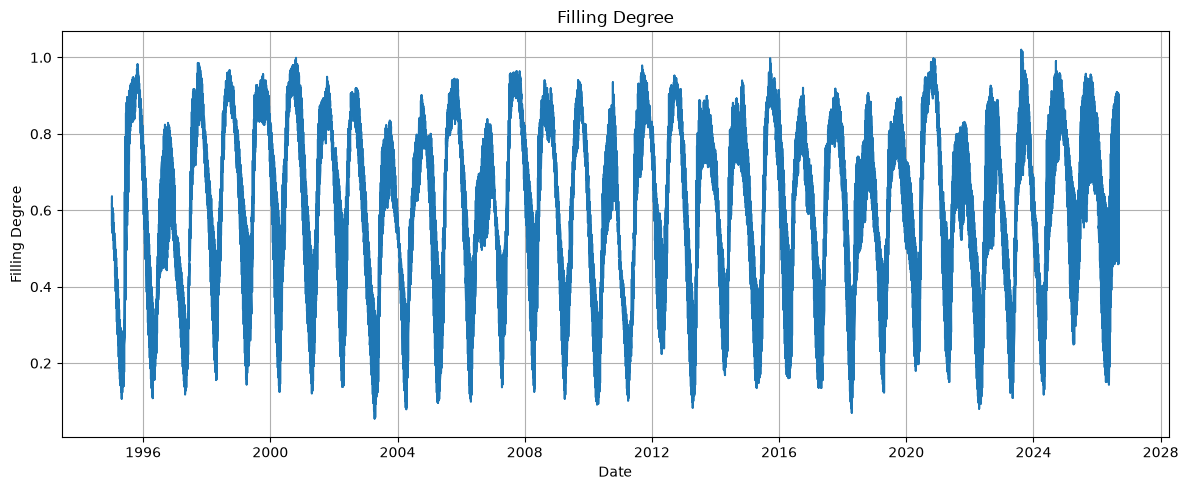

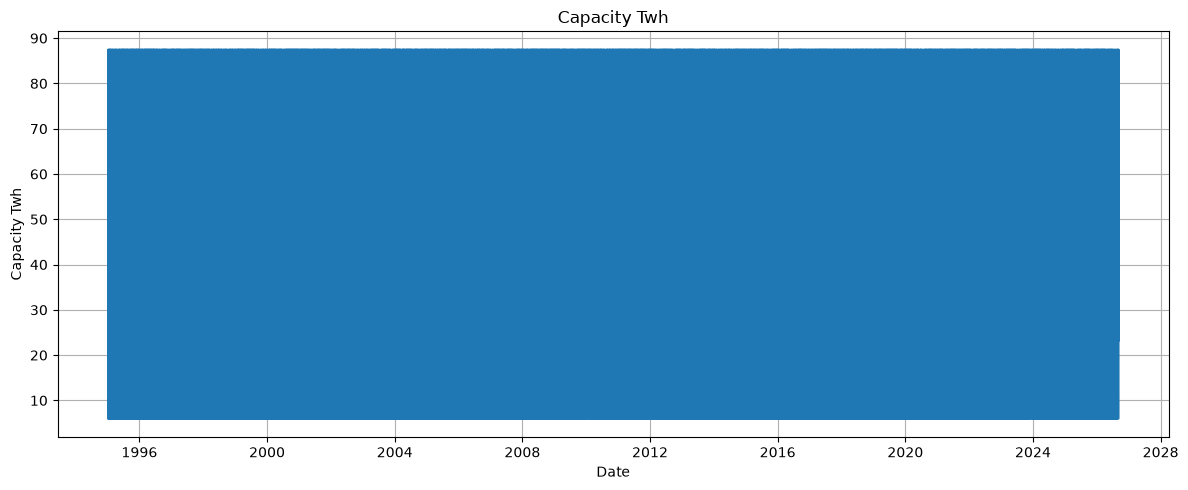

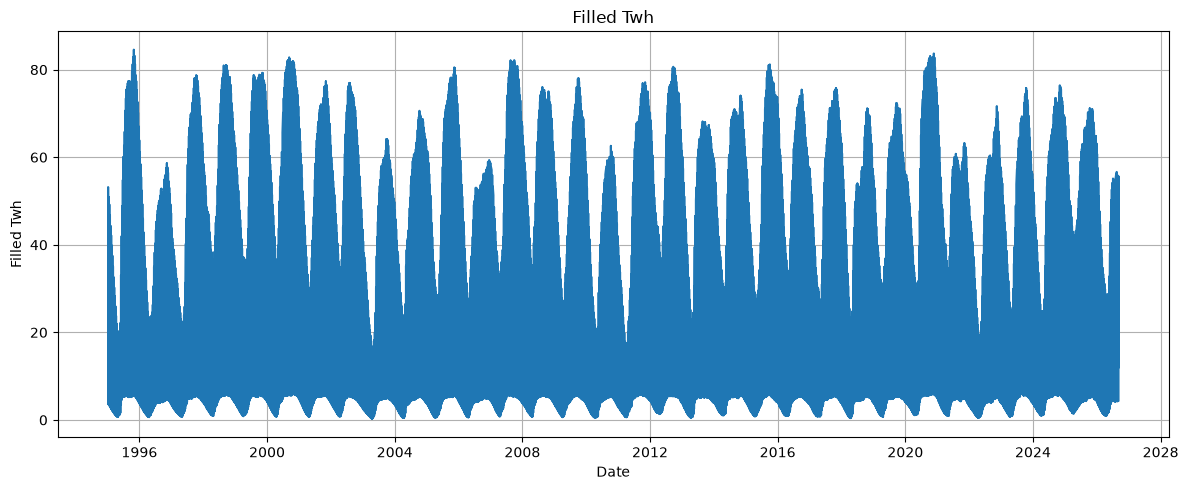

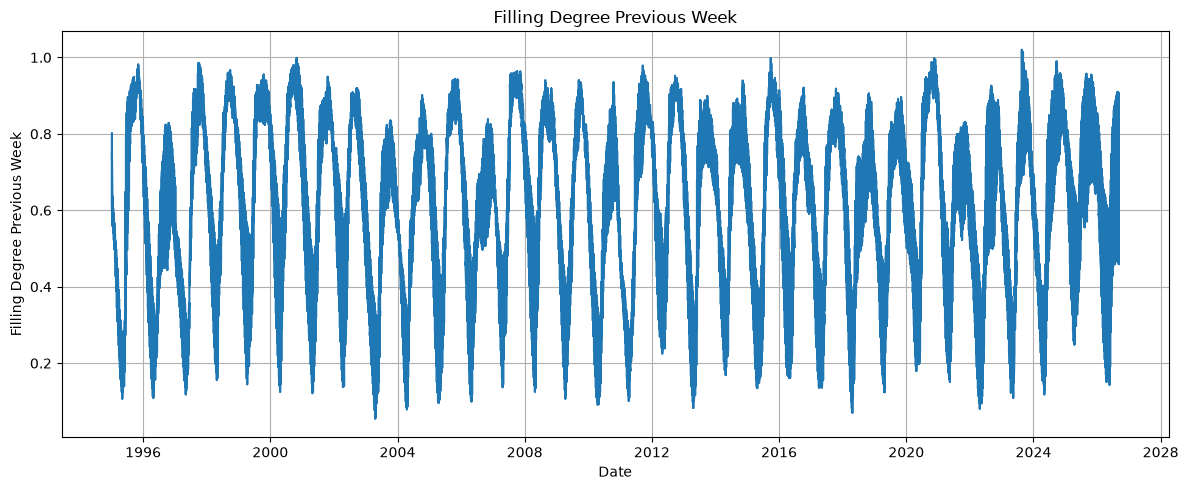

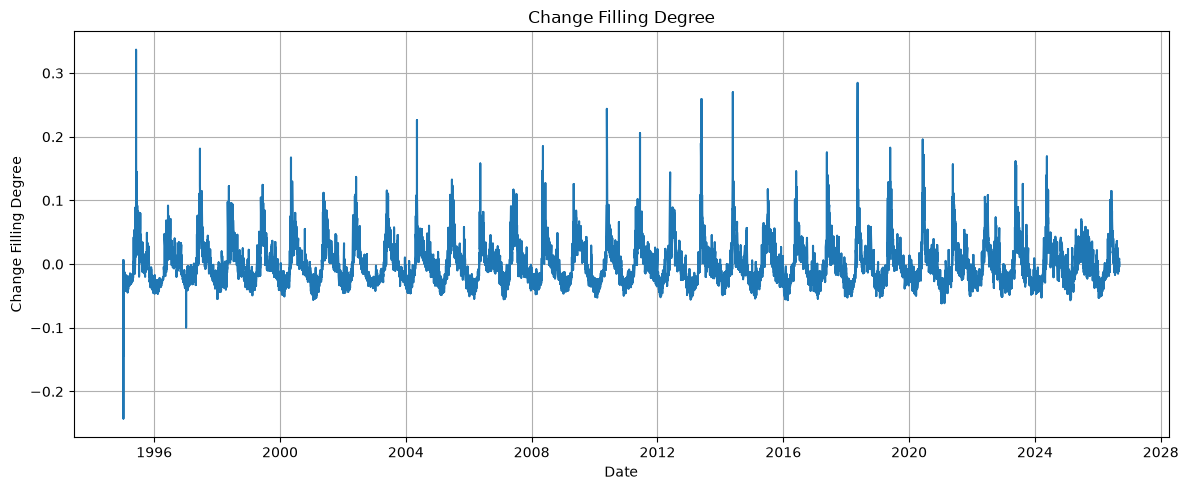

In [11]:
# Create one time-series plot for each selected variable
plot_df = df.sort_values("date")

for column in plot_columns:
    plt.figure(figsize=(12, 5))
    plt.plot(plot_df["date"], plot_df[column])
    plt.title(column.replace("_", " ").title())
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 8. Combined Plot



In [12]:
# Standardize the numerical variables so that they can be compared
# despite having different units and scales.
standardized_df = plot_df[plot_columns].copy()

standardized_df = (
    plot_df[plot_columns] - plot_df[plot_columns].mean()
) / plot_df[plot_columns].std()

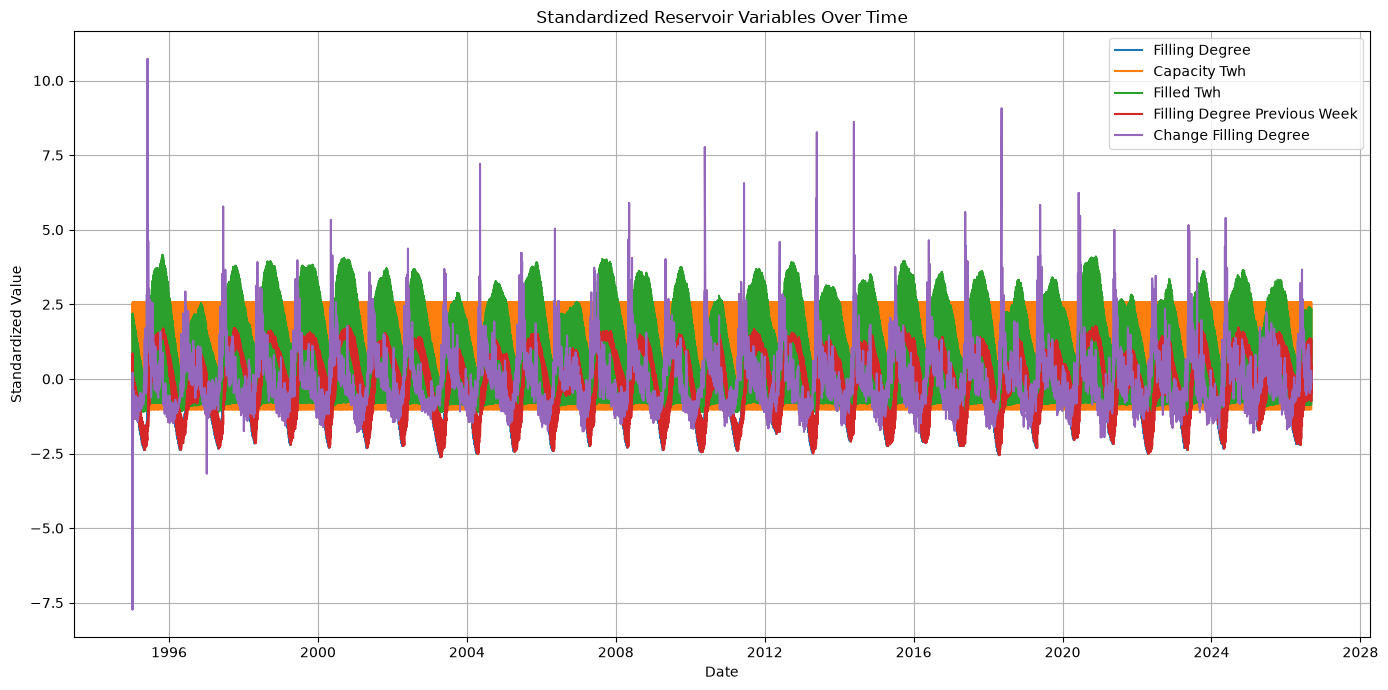

In [13]:
# Plot all standardized variables together
plt.figure(figsize=(14, 7))

for column in plot_columns:
    plt.plot(
        plot_df["date"],
        standardized_df[column],
        label=column.replace("_", " ").title()
    )

plt.title("Standardized Reservoir Variables Over Time")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Standardization is used for the combined plot because the variables have different units and scales. By subtracting the mean and dividing by the standard deviation, the variables are placed on a comparable scale. The resulting values show how far each observation is from the variable's mean, measured in standard deviations.

## 9. Streamlit Application


The Streamlit application provides an online version of the project. It reads the same reservoir dataset from a CSV file and provides interactive data exploration and visualization.

The application is available at:

**GitHub:** https://github.com/M03ZGH/ind320-app

**Streamlit:** https://ind320-app-wktckrzn7uk2axexipgwwq.streamlit.app

## 10. Compulsory Work Log

The first part of the IND320 project gave me experience with both Jupyter Notebook and Streamlit, while also introducing a workflow involving GitHub and a separate development environment.

I started by importing the reservoir dataset into a Jupyter Notebook using Pandas. I inspected the structure of the dataset, renamed the Norwegian column names to understandable English names, converted the relevant date columns to datetime format, and explored the data using descriptive statistics and checks for missing values. I also investigated the different reservoir areas and the time period covered by the dataset.

For the visualization part, I created separate time-series plots for the main reservoir variables. Since the variables have different units and scales, plotting them directly together would make some variables difficult to interpret. I therefore standardized the selected variables for the combined plot, allowing their developments over time to be compared on the same scale.

I then developed the Streamlit application as an interactive version of the project. The application reads the same CSV file as the notebook and uses caching to avoid unnecessarily reloading the data. I created separate pages for the home page, data overview and visualization. The data page displays the imported variables in a table, including line charts for numerical values from the first month. The visualization page allows the user to select a variable and a time period using Streamlit's interactive controls.

During the development process, I encountered several technical issues, particularly related to the Python environment, package dependencies, Streamlit and data types. I used `uv` to manage the project environment and dependencies and used GitHub to keep track of the project files. I also learned how a Streamlit application can be connected to a GitHub repository and deployed online through Streamlit Community Cloud.

AI tools were used throughout the project as both a programming and writing support tool. At the beginning of the project, Claude Code was used to help me understand the course structure, project setup and the development workflow. During the implementation, AI was used to understand Python and Streamlit functionality, troubleshoot errors, discuss possible solutions and improve code structure. GitHub Copilot also provided coding suggestions during development. AI tools were additionally used to support the writing process, including improving the wording, structure and clarity of the notebook documentation and project text. All suggestions were reviewed and adapted to the project requirements rather than being used without modification.

Overall, the project gave me practical experience with a complete workflow from data loading and exploration to visualization, application development and online deployment.
